<a href="https://colab.research.google.com/github/CorinnnaZ/CompChallenge/blob/main/task12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 12
Create a dynamic model of the path of a beam of white light through a triangular prism.

# 12A
- Manually make a triangle that varies with angle alpha ($\alpha$).
- The slider (to be ran in Colab) will adjust the incident angle only (and we're calling it a day)
- Effectively use the stuff from 12B for the points and just work on the visualisation for this task

In [ ]:
# NEXT STEPS:
# - plotting them wrt to the triangle (specific domains and thingies working out)
# - get this dynamically plotting
# - add the colours (rainbow) with the frequency allowing for many different angles to be plotted (and their respective calculations being done by hand before progressing)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as ipy
import pandas as pd

In [ ]:
# hand calculations of the code, functioning dynamically
def plotting(incident):
    alpha = 45 # degrees
    n_glass = 1.5 # unitless

    # incident angle
    theta_1 =  np.radians(incident) # degrees

    # refracted angle
    theta_2 = np.arcsin((np.sin((theta_1))) / n_glass)

    # internal angle
    theta_3 = alpha - theta_2

    # emergent angle
    theta_4 = np.arcsin(n_glass * np.sin(theta_3))

    df = pd.DataFrame([{
        "Incident": theta_1,
        "Refracted": theta_2,
        "Internal": theta_3,
        "Emergent": theta_4
        }])

    print(df)

In [ ]:
ipy.interact(plotting, incident=(-90, 90, 1))

interactive(children=(IntSlider(value=0, description='incident', max=90, min=-90), Output()), _dom_classes=('w…

<function __main__.plotting(incident)>

In [ ]:
# ISSUES
"""
- organise the code into sections and write what each of it specifically does (Claude or any of the others are not helping at all which makes this frustrating)

- each area of the code contains:
    - variable definitions
    - variable calculations
    - plotting function (e.g. ax.scatter)
    Notes are embedded within this but each of the sections should be self contained
- then work on the issues as prescribed
"""

# 1. GET REFRACTED RAY PLOTTING WELL
# 2. GET EMERGENT
"""
If refracted_ray intersects with min_y in refracted_domain:
    - appropriate plotting, everything else stops here
    - title changes such that it does not include the emergent ray bit
Else:
    - emergent ray calculations
    - plot emergent ray
    - change title accordingly
"""
# 3. CHANGE [ID] ON SLIDER AS WELL

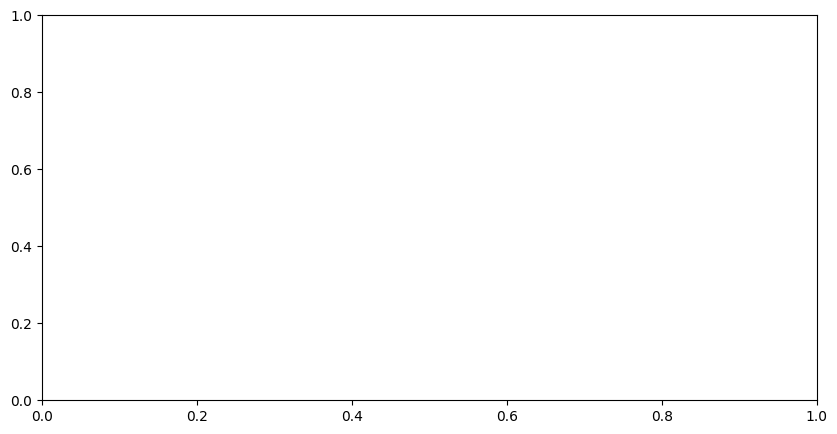

In [26]:
fig, ax = plt.subplots(figsize=(10,5))

def plotting_function(alpha, incident_angle, n_glass):

    ax.clear()

    # triangle plot
    x = np.arange(-100, 100, 1)
    func_x = np.tan(np.radians(alpha)) * x
    y = - np.abs(func_x)

    min_y = [min(y)] * len(x) # array that forms base of triangle

    ax.plot(x, y, color='k')
    ax.plot(x, min_y, color='k')
    # -------------#


    # normal line (on incident ray)
    id = int(len(x)/4)
    entrance_x, entrance_y = x[id], y[id] # where the incident ray refracts on the prism

    normal_incident_domain = np.arange((entrance_x -40), (entrance_x + 40), 1)
    normal_incident_gradient = -1 / (np.tan(np.radians(alpha)))
    normal_incident_range = normal_incident_gradient * (normal_incident_domain - entrance_x) + entrance_y

    ax.plot(normal_incident_domain, normal_incident_range,'--')


    # incident
    incident_domain = np.arange(-100, entrance_x, 1)
    incident_gradient = -1 / (np.tan(np.radians(alpha + incident_angle)))
    incident_range = incident_gradient * (incident_domain - entrance_x) + entrance_y

    ax.plot(incident_domain, incident_range, 'b-', label='Incident')


    # refracted
    refracted_angle = np.degrees(np.arcsin((np.sin(np.radians(incident_angle))) / n_glass)) # n_air == 1
    refracted_gradient = -1 / np.tan(np.radians(alpha + refracted_angle))


    x_a, y_a = entrance_x, entrance_y # some coordinates from the refracted ray
    x_b, y_b = 0, 0 # coordinates from the tangential point
    m_a, m_b = refracted_gradient, - np.tan(np.radians(alpha)) # respective gradients from both

    refracted_intersect_x = ((x_a * m_a) - (x_b * m_b) + (y_b) - (y_a)) / (m_a - m_b)
    refracted_intersect_y = ((y_a * m_b) - (y_b * m_a) + (x_b * m_a * m_b) - (x_a * m_b * m_a)) / (m_b - m_a)

    refracted_domain = np.arange(x[id], refracted_intersect_x, 1)

    refracted_range = refracted_gradient * (refracted_domain - refracted_intersect_x) + refracted_intersect_y


    ax.plot(refracted_domain, refracted_range, 'b-', label='Refracted')

    # internal angle

    # emergent ray
    print(f"incident ray: {incident_angle}\nrefracted ray: {refracted_angle}")
    print(f"coordinates of entrance point: {entrance_x}, {entrance_y}\ncoordinates of exit point: {refracted_intersect_x}, {refracted_intersect_y}")

    ax.set_title(rf"$\alpha$ = {alpha}$^\circ$, $\theta_i$ = {incident_angle}$^\circ$, $\theta_r$ = {refracted_angle:.3f}$^\circ$, $\theta_e$ = emergent_angle$^\circ$")
    ax.set_xlim(min(x), max(x))
    ax.set_ylim(min(y)-.5, .5)
    ax.set_aspect(1)

    ax.legend()
    ax.grid()
    display(fig)

In [28]:
ipy.interact(plotting_function, alpha=(0,90,1), incident_angle=(0, 90, 1), n_glass=(1, 2, 0.05))

interactive(children=(IntSlider(value=45, description='alpha', max=90), IntSlider(value=45, description='incid…

<function __main__.plotting_function(alpha, incident_angle, n_glass)>

In [16]:
print(0/5)

0.0


# 12B
## Extension Opportunities
- Label all asymptotes and derivatives (and allude to their significance in the video that must be made)
- Plot the relationship between the asymptotic changes as alpha changes and see if there is some existing law relating to that.

In [ ]:
## modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm # colour mapping w/ matplotlib

## constants
n_air = 1
frequency = 542.5 * (10 ** 12)
wavelength = (299792458 / frequency) * 1e6 # converted to nanometres (to work for sellmeier equation)
alpha = 45 # (degrees)
alpha_list = np.arange(10, 85, .025) # change to np.arange(10,85,5)

## refractive index of crown glass
a = [1.03961212, 0.231792344, 1.01146945]
b = [0.00600069867, 0.0200179144, 103.560653]
summation = []
for i in range(len(a)):
  s = (a[i] * (wavelength ** 2))/((wavelength ** 2) - b[i])
  summation.append(s)
n_glass = np.sqrt(1 + sum(summation))
print(f"Refractive index: {n_glass}")

## equations

### angles
theta_1 = np.radians(np.linspace(0, 90, 1000)) # incident angle
theta_2 = np.arcsin((n_air/n_glass)*np.sin(theta_1)) # refracted angle
theta_3 = np.radians(alpha) - theta_2 # internal incident angle
theta_4 = np.arcsin((n_glass/n_air) * np.sin(theta_3))

### deflection
delta = theta_1 + theta_4 - np.radians(alpha)

"""
## table of results
df = pd.DataFrame({
    'Incident Angle': theta_1,
    'Refracted Angle': theta_2,
    'Internal Incident Angle': theta_3,
    'Emergent Ray Angle': theta_4
})
"""

## plot
fig, (ax1, ax2, ax3) = plt.subplots(3, figsize=(9,18))
ax1.plot(theta_1, theta_4)
ax1.set_xlabel('Incident Angle /rad')
ax1.set_ylabel('Emergent Ray Angle /rad')
ax1.set_title(r'$\theta_i$ vs $\theta_t$ given $\alpha$=45$^\circ$, f=542.5THz')
ax1.set_xlim(np.radians(0), np.radians(90))

ax2.plot(theta_1, delta)
ax2.set_xlabel('Incident Angle /rad')
ax2.set_ylabel('Deflection /rad')
ax2.set_title("Deflection Angle")

colours = cm.rainbow(np.linspace(0, 1, len(alpha_list)))

# some super inefficient stuff
for i in range(len(alpha_list)):
  alpha = alpha_list[i]
  ### angles
  theta_1 = np.radians(np.linspace(0, 90, 1000)) # incident angle
  theta_2 = np.arcsin((n_air/n_glass)*np.sin(theta_1)) # refracted angle
  theta_3 = np.radians(alpha) - theta_2 # internal incident angle
  theta_4 = np.arcsin((n_glass/n_air) * np.sin(theta_3))

  ### deflection
  delta = theta_1 + theta_4 - np.radians(alpha)

  ax3.plot(theta_1, delta, label = rf"$\alpha$ = {alpha}$^\circ$", color = colours[i])


ax3.set_xlabel('Incident Angle /rad')
ax3.set_ylabel('Deflection /rad')
ax3.set_title(r"Deflection Angle ($\delta$), for $\alpha$ $\in [10,80]$")
ax3.set_xlim(np.radians(0), np.radians(90))
# ax3.legend(bbox_to_anchor=(1.005, 1), loc = 'upper left', fontsize = 'small', fancybox = True)

plt.tight_layout()
plt.show()

## print


Refractive index: 1.5183908287640628


/tmp/ipython-input-72-3091474910.py:30: RuntimeWarning: invalid value encountered in arcsin
  theta_4 = np.arcsin((n_glass/n_air) * np.sin(theta_3))
/tmp/ipython-input-72-3091474910.py:66: RuntimeWarning: invalid value encountered in arcsin
  theta_4 = np.arcsin((n_glass/n_air) * np.sin(theta_3))
/tmp/ipython-input-72-3091474910.py:80: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
